# Interprétation — BRFSS Heart Disease (modèle lifestyle)

Objectif : comprendre les facteurs prédictifs du modèle déclaratif, les comparer au modèle
clinique, et cerner les limites propres aux données auto-déclarées.

On repart des artefacts sauvegardés par `python -m src.train_model`
(`models/heart_disease/metrics.json`).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

with open("../../models/heart_disease/metrics.json") as f:
    summary = json.load(f)

print("Meilleur modèle :", summary["best_model"])
best = summary["models"][summary["best_model"]]
print(f"ROC-AUC : {best['roc_auc']:.3f} | Accuracy : {best['accuracy']:.3f} | "
      f"Recall : {best['recall']:.3f} | Précision : {best['precision']:.3f}")

Meilleur modèle : LightGBM
ROC-AUC : 0.836 | Accuracy : 0.736 | Recall : 0.789 | Précision : 0.251


## 1. Quels facteurs pèsent le plus ?

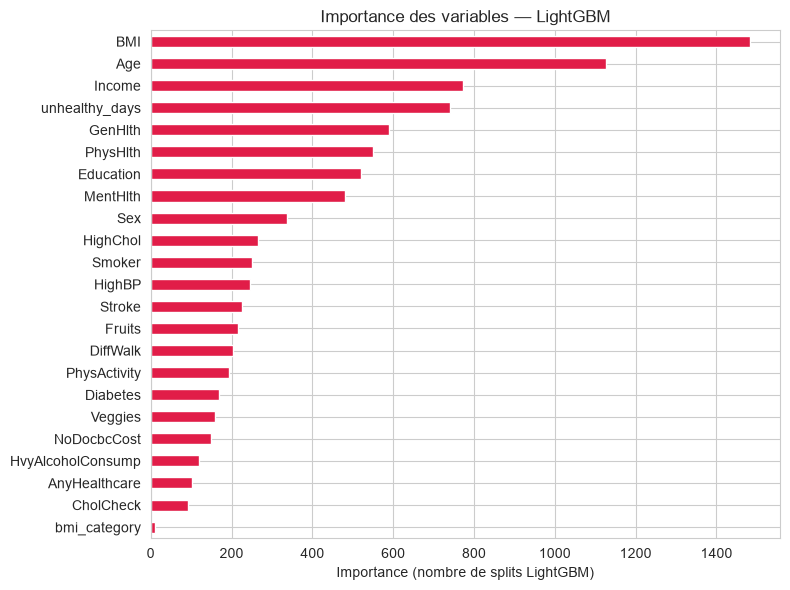

BMI               1483
Age               1127
Income             772
unhealthy_days     741
GenHlth            590
PhysHlth           549
Education          521
MentHlth           481
Sex                336
HighChol           266
Smoker             250
HighBP             245
dtype: int64

In [2]:
importance = pd.Series(summary["feature_importance"]).abs().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importance.sort_values().plot.barh(color="#e11d48")
plt.title(f"Importance des variables — {summary['best_model']}")
plt.xlabel("Importance (nombre de splits LightGBM)")
plt.tight_layout()
plt.show()

importance.head(12)

## 2. Lecture des résultats

- **IMC et âge** dominent — les deux seuls proxys "physiques" disponibles dans cette enquête
  téléphonique.
- **Le contexte socio-économique pèse lourd** : `Income` (revenu) est 3ᵉ, `Education` 7ᵉ. Le
  gradient social de santé est un résultat classique en épidémiologie : revenus faibles →
  moindre accès aux soins, alimentation moins équilibrée, stress chronique.
- **La santé perçue est très prédictive** : `GenHlth` (auto-évaluation Excellent→Mauvais),
  `PhysHlth`/`MentHlth` et la variable dérivée `unhealthy_days` captent un signal global de
  fragilité qu'aucune variable clinique isolée ne mesure.
- **Le déclaratif "médical" (HighBP, HighChol) pèse moins qu'attendu** : ces variables binaires
  auto-déclarées sont moins riches qu'une mesure réelle de tension — à comparer avec le modèle
  clinique où la tension mesurée domine tout.

## 3. Comparaison avec le modèle clinique

| | Cardio Train (clinique) | BRFSS (lifestyle) |
|---|---|---|
| Meilleur modèle | Random Forest | LightGBM |
| ROC-AUC | 0.807 | 0.836 |
| Facteur n°1 | Pression artérielle mesurée | IMC |
| Nature du signal | Physiologique | Socio-comportemental + santé perçue |

Le ROC-AUC lifestyle est *supérieur* — non pas parce que les données déclaratives sont
"meilleures", mais parce que le dataset est 3× plus grand et que la tâche diffère (dépistage
populationnel vs diagnostic sur cohorte hospitalière équilibrée). Les deux modèles sont
complémentaires : H2 (« les données cliniques prédisent mieux ») n'est donc pas confirmée telle
quelle — c'est la *richesse* et le *volume* du signal qui comptent plus que sa nature clinique.

## 4. Limites

- **Toutes les variables sont auto-déclarées** : sous-déclaration probable du tabac/alcool,
  IMC calculé sur taille/poids déclarés.
- **F1 bas (~0.38)** : le modèle génère beaucoup de fausses alertes — acceptable pour du
  dépistage, inutilisable pour du diagnostic.
- L'importance LightGBM (nombre de splits) favorise les variables continues.
- Enquête USA 2015 : généralisation limitée à d'autres pays/époques.